# 01. Introduction

Notebook này tiếp nối `03_feature_engineering_models.ipynb` và `04_imbalance_handling_models.ipynb` cho project **Gym Customer Churn Prediction**.

Trong churn prediction, business không chỉ cần biết **khách hàng nào có khả năng churn**, mà còn cần biết **vì sao họ có rủi ro churn** để đưa ra hành động retention phù hợp.

SHAP giúp giải thích model ở hai cấp độ:

- **Global explainability:** feature nào ảnh hưởng nhiều nhất đến toàn bộ model.
- **Local explainability:** vì sao một khách hàng cụ thể có churn probability cao hoặc thấp.

Mục tiêu cuối cùng là biến prediction thành **retention strategy**: xác định churn drivers, phân nhóm rủi ro, và đề xuất hành động chăm sóc khách hàng dựa trên nguyên nhân cụ thể.


# 02. Import Libraries


In [18]:
import os
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.ensemble import GradientBoostingClassifier

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except ImportError:
    CatBoostClassifier = None
    CATBOOST_AVAILABLE = False
    print("catboost is not installed. Fallback model GradientBoostingClassifier will be used.")

try:
    import shap
    SHAP_AVAILABLE = True
    shap.initjs()
except ImportError:
    shap = None
    SHAP_AVAILABLE = False
    print("shap is not installed. SHAP-specific plots will be skipped; fallback feature importance will still run.")

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
TARGET_COL = "Churn"

sns.set_theme(style="whitegrid", context="notebook", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["axes.unicode_minus"] = False

pd.set_option("display.max_rows", 220)
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("CatBoost available:", CATBOOST_AVAILABLE)
print("SHAP available:", SHAP_AVAILABLE)


CatBoost available: True
SHAP available: True


# 03. Load Dataset

Load dataset gốc, kiểm tra shape, vài dòng đầu, danh sách cột và phân phối target.


In [19]:
PROJECT_NAME = "Gym Customer Churn Prediction"
DATA_PATH_CANDIDATES = [
    Path(r"D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\Data\gym_churn_us.csv"),
    Path.cwd() / "Data" / "gym_churn_us.csv",
    Path.cwd().parent / "Data" / "gym_churn_us.csv",
]

DATA_PATH = next((p for p in DATA_PATH_CANDIDATES if p.exists()), DATA_PATH_CANDIDATES[0])
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found. Tried: {[str(p) for p in DATA_PATH_CANDIDATES]}")

PROJECT_ROOT = DATA_PATH.parent.parent
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"
MODELS_DIR = PROJECT_ROOT / "models"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Project: {PROJECT_NAME}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]:,} columns")
display(df.head())
print("Columns:")
print(df.columns.tolist())

if TARGET_COL not in df.columns:
    raise KeyError(f"Target column {TARGET_COL} not found.")

target_distribution = pd.DataFrame({
    "count": df[TARGET_COL].value_counts().sort_index(),
    "percentage": (df[TARGET_COL].value_counts(normalize=True).sort_index() * 100).round(2),
})
display(target_distribution)


Project: Gym Customer Churn Prediction
Project root: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn
Dataset shape: 4,000 rows x 14 columns


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,Churn
0,1,1,1,1,0,6,1,29,14.2275,5.0000,3,0.0204,0.0000,0
1,0,1,0,0,1,12,1,31,113.2029,12.0000,7,1.9229,1.9102,0
2,0,1,1,0,1,1,0,28,129.4485,1.0000,2,1.8591,1.7365,0
3,0,1,1,1,1,12,1,33,62.6699,12.0000,2,3.2056,3.3572,0
4,1,1,1,1,1,1,0,26,198.3623,1.0000,3,1.1139,1.1201,0


Columns:
['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Contract_period', 'Group_visits', 'Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month', 'Churn']


,count,percentage
Churn,,
0,2939,73.4700
1,1061,26.5200


# 04. Define Features and Target


In [20]:
ORIGINAL_FEATURES = [
    "gender",
    "Near_Location",
    "Partner",
    "Promo_friends",
    "Phone",
    "Contract_period",
    "Group_visits",
    "Age",
    "Avg_additional_charges_total",
    "Month_to_end_contract",
    "Lifetime",
    "Avg_class_frequency_total",
    "Avg_class_frequency_current_month",
]

missing_features = [c for c in ORIGINAL_FEATURES if c not in df.columns]
if missing_features:
    print("Warning: missing original features will be skipped:", missing_features)

original_features = [c for c in ORIGINAL_FEATURES if c in df.columns]
X_original = df[original_features].copy()
y = df[TARGET_COL].copy()

print("Original features:", original_features)
print("X_original shape:", X_original.shape)
print("y shape:", y.shape)


Original features: ['gender', 'Near_Location', 'Partner', 'Promo_friends', 'Phone', 'Contract_period', 'Group_visits', 'Age', 'Avg_additional_charges_total', 'Month_to_end_contract', 'Lifetime', 'Avg_class_frequency_total', 'Avg_class_frequency_current_month']
X_original shape: (4000, 13)
y shape: (4000,)


# 05. Train-Test Split

Dùng split giống các notebook trước: 20% test set, stratify theo target và random_state=42 để giữ tỷ lệ churn ổn định.


In [21]:
X_train_original, X_test_original, y_train, y_test = train_test_split(
    X_original,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("X_train_original:", X_train_original.shape)
print("X_test_original:", X_test_original.shape)
print("Train churn distribution:")
display(pd.DataFrame({
    "count": y_train.value_counts().sort_index(),
    "percentage": (y_train.value_counts(normalize=True).sort_index() * 100).round(2),
}))
print("Test churn distribution:")
display(pd.DataFrame({
    "count": y_test.value_counts().sort_index(),
    "percentage": (y_test.value_counts(normalize=True).sort_index() * 100).round(2),
}))


X_train_original: (3200, 13)
X_test_original: (800, 13)
Train churn distribution:


,count,percentage
Churn,,
0,2351,73.4700
1,849,26.5300


Test churn distribution:


,count,percentage
Churn,,
0,588,73.5000
1,212,26.5000


# 06. Feature Engineering

Feature engineering giống notebook 03. Function chỉ nhận input features, không nhận target, không tạo feature từ Churn và không sửa data gốc.

Spending thresholds được tính từ train set rồi apply cho test set để tránh data leakage.


In [22]:
def get_col(data: pd.DataFrame, column: str, default=0):
    """Safely return a column or a default-valued Series if missing."""
    if column in data.columns:
        return data[column]
    return pd.Series(default, index=data.index)


def calculate_feature_thresholds(X_train_data: pd.DataFrame) -> dict:
    """Fit feature engineering thresholds on training data only."""
    if "Avg_additional_charges_total" not in X_train_data.columns:
        return {"spending_q25": 0, "spending_q75": 0}
    return {
        "spending_q25": X_train_data["Avg_additional_charges_total"].quantile(0.25),
        "spending_q75": X_train_data["Avg_additional_charges_total"].quantile(0.75),
    }


def create_features(data: pd.DataFrame, thresholds: dict | None = None) -> pd.DataFrame:
    """Create engineered features from input X only. This function never uses target."""
    df_fe = data.copy()
    eps = 1e-6

    lifetime = get_col(df_fe, "Lifetime")
    freq_total = get_col(df_fe, "Avg_class_frequency_total")
    freq_current = get_col(df_fe, "Avg_class_frequency_current_month")
    contract_period = get_col(df_fe, "Contract_period")
    month_to_end = get_col(df_fe, "Month_to_end_contract")
    additional_charges = get_col(df_fe, "Avg_additional_charges_total")
    near_location = get_col(df_fe, "Near_Location")
    partner = get_col(df_fe, "Partner")
    promo_friends = get_col(df_fe, "Promo_friends")
    phone = get_col(df_fe, "Phone")
    group_visits = get_col(df_fe, "Group_visits")

    # Engagement
    df_fe["frequency_drop"] = freq_total - freq_current
    df_fe["frequency_ratio_current_total"] = freq_current / (freq_total + eps)
    df_fe["low_current_activity"] = (freq_current < 1).astype(int)
    df_fe["high_current_activity"] = (freq_current >= 3).astype(int)
    df_fe["engagement_score"] = lifetime * freq_current
    df_fe["total_engagement_score"] = lifetime * freq_total

    # Contract / renewal
    df_fe["contract_remaining_ratio"] = month_to_end / (contract_period + eps)
    df_fe["is_contract_ending"] = (month_to_end <= 1).astype(int)
    df_fe["is_short_contract"] = (contract_period <= 1).astype(int)
    df_fe["is_long_contract"] = (contract_period >= 12).astype(int)
    df_fe["renewal_pressure_score"] = df_fe["is_contract_ending"] * df_fe["is_short_contract"]

    # Loyalty
    df_fe["is_new_customer"] = (lifetime <= 1).astype(int)
    df_fe["is_loyal_customer"] = (lifetime >= 6).astype(int)
    df_fe["lifetime_per_contract"] = lifetime / (contract_period + eps)
    df_fe["loyalty_score"] = lifetime * contract_period

    # Spending
    if thresholds is None:
        spending_q25 = additional_charges.quantile(0.25)
        spending_q75 = additional_charges.quantile(0.75)
    else:
        spending_q25 = thresholds.get("spending_q25", additional_charges.quantile(0.25))
        spending_q75 = thresholds.get("spending_q75", additional_charges.quantile(0.75))
    df_fe["spending_per_month"] = additional_charges / (lifetime + 1)
    df_fe["high_spending"] = (additional_charges >= spending_q75).astype(int)
    df_fe["low_spending"] = (additional_charges <= spending_q25).astype(int)

    # Convenience / social
    df_fe["convenience_score"] = near_location + partner + promo_friends + phone
    df_fe["social_commitment_score"] = group_visits + promo_friends + partner
    df_fe["far_no_group"] = ((near_location == 0) & (group_visits == 0)).astype(int)
    df_fe["no_contact_info"] = (phone == 0).astype(int)

    # Interactions
    df_fe["new_low_activity"] = df_fe["is_new_customer"] * df_fe["low_current_activity"]
    df_fe["ending_low_activity"] = df_fe["is_contract_ending"] * df_fe["low_current_activity"]
    df_fe["far_low_activity"] = (1 - near_location) * df_fe["low_current_activity"]
    df_fe["short_contract_low_activity"] = df_fe["is_short_contract"] * df_fe["low_current_activity"]
    df_fe["no_group_low_activity"] = (1 - group_visits) * df_fe["low_current_activity"]
    df_fe["partner_long_contract"] = partner * df_fe["is_long_contract"]
    df_fe["promo_group"] = promo_friends * group_visits

    # Log features
    df_fe["log_lifetime"] = np.log1p(lifetime.clip(lower=0))
    df_fe["log_additional_charges"] = np.log1p(additional_charges.clip(lower=0))
    df_fe["log_frequency_current"] = np.log1p(freq_current.clip(lower=0))
    df_fe["log_frequency_total"] = np.log1p(freq_total.clip(lower=0))

    return df_fe.replace([np.inf, -np.inf], np.nan).fillna(0)


feature_thresholds = calculate_feature_thresholds(X_train_original)
X_train_fe = create_features(X_train_original, thresholds=feature_thresholds)
X_test_fe = create_features(X_test_original, thresholds=feature_thresholds)

print("X_train_fe shape:", X_train_fe.shape)
print("X_test_fe shape:", X_test_fe.shape)
print("New feature count:", X_train_fe.shape[1] - X_train_original.shape[1])
display(pd.DataFrame({
    "dataset": ["X_train_fe", "X_test_fe"],
    "missing_values": [int(X_train_fe.isna().sum().sum()), int(X_test_fe.isna().sum().sum())],
    "infinite_values": [int(np.isinf(X_train_fe.to_numpy()).sum()), int(np.isinf(X_test_fe.to_numpy()).sum())],
}))


X_train_fe shape: (3200, 46)
X_test_fe shape: (800, 46)
New feature count: 33


,dataset,missing_values,infinite_values
0,X_train_fe,0,0
1,X_test_fe,0,0


# 07. Train Best Model

Train lại best model hiện tại: **CatBoost + Feature Engineering**. Nếu CatBoost chưa được cài trong môi trường, notebook dùng fallback GradientBoostingClassifier để vẫn chạy end-to-end, nhưng phần diễn giải chính vẫn được thiết kế cho CatBoost.


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,CatBoost + Feature Engineering,0.9575,0.9495,0.8868,0.9171,0.9896


Classification report:


,precision,recall,f1-score,support
0,0.9601,0.9830,0.9714,588.0000
1,0.9495,0.8868,0.9171,212.0000
accuracy,0.9575,0.9575,0.9575,0.9575
macro avg,0.9548,0.9349,0.9443,800.0000
weighted avg,0.9573,0.9575,0.9570,800.0000


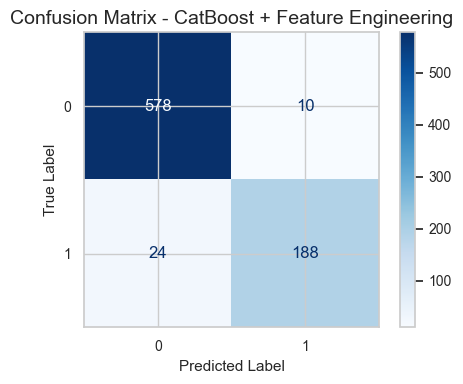

Saved model artifact to: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\models\catboost_fe_shap_model.pkl


In [23]:
if CATBOOST_AVAILABLE:
    model = CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=0,
    )
    model_name = "CatBoost + Feature Engineering"
else:
    model = GradientBoostingClassifier(random_state=RANDOM_STATE)
    model_name = "GradientBoosting fallback + Feature Engineering"

model.fit(X_train_fe, y_train)
y_pred = model.predict(X_test_fe)
y_proba = model.predict_proba(X_test_fe)[:, 1]

metrics = {
    "Model": model_name,
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1": f1_score(y_test, y_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, y_proba),
}
display(pd.DataFrame([metrics]))
print("Classification report:")
display(pd.DataFrame(classification_report(y_test, y_pred, output_dict=True, zero_division=0)).T)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues", ax=ax, values_format="d")
ax.set_title(f"Confusion Matrix - {model_name}")
ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_model_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

model_path = MODELS_DIR / "catboost_fe_shap_model.pkl"
model_artifact = {
    "model": model,
    "model_name": model_name,
    "feature_thresholds": feature_thresholds,
    "original_features": original_features,
    "feature_engineered_columns": X_train_fe.columns.tolist(),
    "metrics": metrics,
}
joblib.dump(model_artifact, model_path)
print(f"Saved model artifact to: {model_path}")


# 08. Global Feature Importance from CatBoost

CatBoost feature importance cho biết feature nào được model dùng nhiều, nhưng chưa cho biết hướng tác động tăng hay giảm churn. Vì vậy ta dùng phần này như baseline interpretability, sau đó dùng SHAP để phân tích sâu hơn.


,feature,catboost_importance
13,frequency_drop,21.6785
7,Age,11.6280
27,loyalty_score,8.6169
14,frequency_ratio_current_total,6.3865
17,engagement_score,5.8935
18,total_engagement_score,4.3710
28,spending_per_month,4.0889
43,log_additional_charges,3.7603
42,log_lifetime,2.8203
11,Avg_class_frequency_total,2.6510


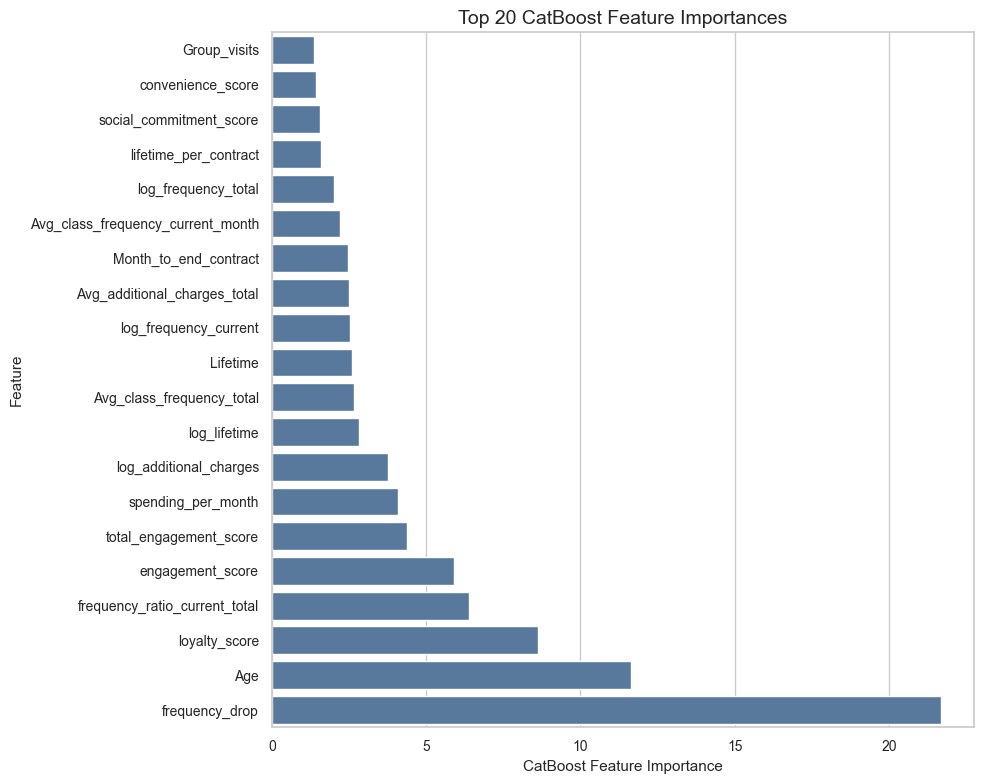

In [24]:
if hasattr(model, "feature_importances_"):
    catboost_importance_df = pd.DataFrame({
        "feature": X_train_fe.columns,
        "catboost_importance": model.feature_importances_,
    }).sort_values("catboost_importance", ascending=False)
else:
    catboost_importance_df = pd.DataFrame({"feature": X_train_fe.columns, "catboost_importance": 0})

display(catboost_importance_df.head(20))

plt.figure(figsize=(10, 8))
top20_cb = catboost_importance_df.head(20).sort_values("catboost_importance", ascending=True)
sns.barplot(data=top20_cb, x="catboost_importance", y="feature", color="#4C78A8")
plt.title("Top 20 CatBoost Feature Importances")
plt.xlabel("CatBoost Feature Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_catboost_feature_importance_top20.png", dpi=150, bbox_inches="tight")
plt.show()


# 09. SHAP Explainer

Tạo SHAP TreeExplainer cho model. SHAP analysis được thực hiện trên test set để giải thích behavior ngoài train data.

Nếu môi trường không có SHAP, notebook sẽ tạo fallback SHAP table rỗng và các section sau sẽ skip plot tương ứng thay vì lỗi.


In [25]:
if SHAP_AVAILABLE:
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_fe)
    expected_value = explainer.expected_value

    if isinstance(shap_values, list):
        shap_values_churn = shap_values[1]
        expected_value_churn = expected_value[1] if isinstance(expected_value, (list, np.ndarray)) else expected_value
    else:
        shap_values_churn = shap_values
        expected_value_churn = expected_value

    shap_values_churn = np.asarray(shap_values_churn)
    print("shap_values_churn shape:", shap_values_churn.shape)
    print("X_test_fe shape:", X_test_fe.shape)
else:
    explainer = None
    shap_values_churn = np.zeros((X_test_fe.shape[0], X_test_fe.shape[1]))
    expected_value_churn = 0
    print("SHAP is not available. Using zero matrix fallback so downstream tables can still run.")


shap_values_churn shape: (800, 46)
X_test_fe shape: (800, 46)


# 10. SHAP Global Importance

Mean absolute SHAP đo mức ảnh hưởng trung bình của từng feature lên output model. Khác với feature importance truyền thống, SHAP có thể mở rộng sang phân tích hướng tác động ở summary/dependence plots.


Saved SHAP feature importance to: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\reports\shap_feature_importance.csv


,feature,mean_abs_shap
13,frequency_drop,1.6181
7,Age,1.0849
27,loyalty_score,1.0237
14,frequency_ratio_current_total,0.8270
17,engagement_score,0.6137
18,total_engagement_score,0.5464
43,log_additional_charges,0.3409
42,log_lifetime,0.3193
10,Lifetime,0.2938
9,Month_to_end_contract,0.2734


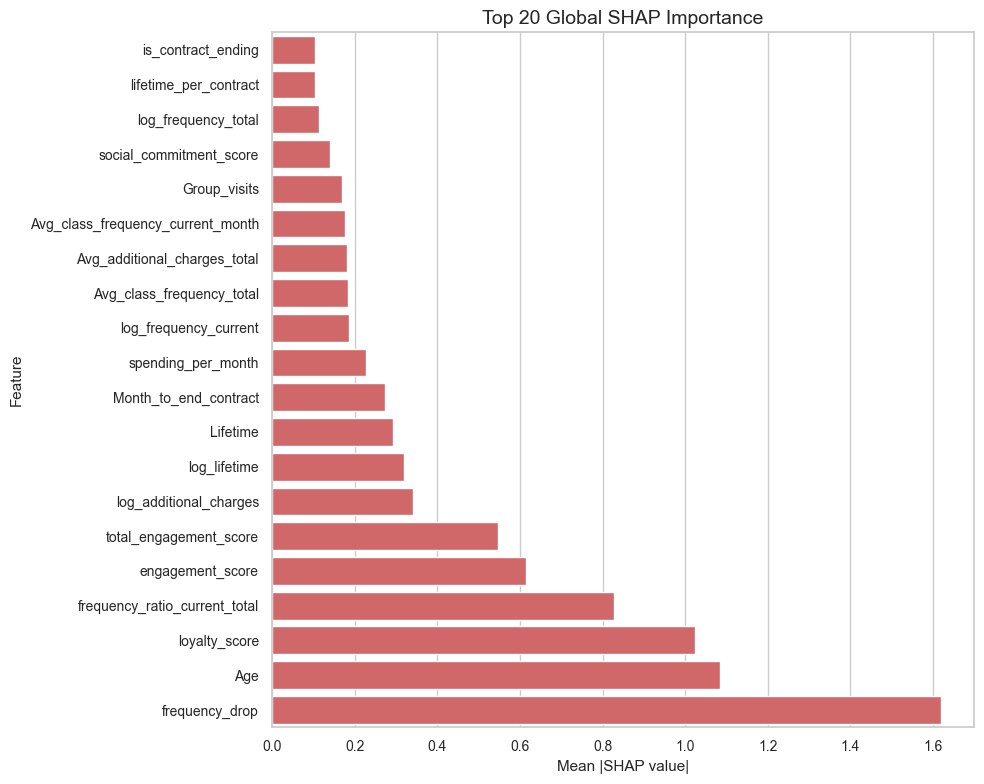

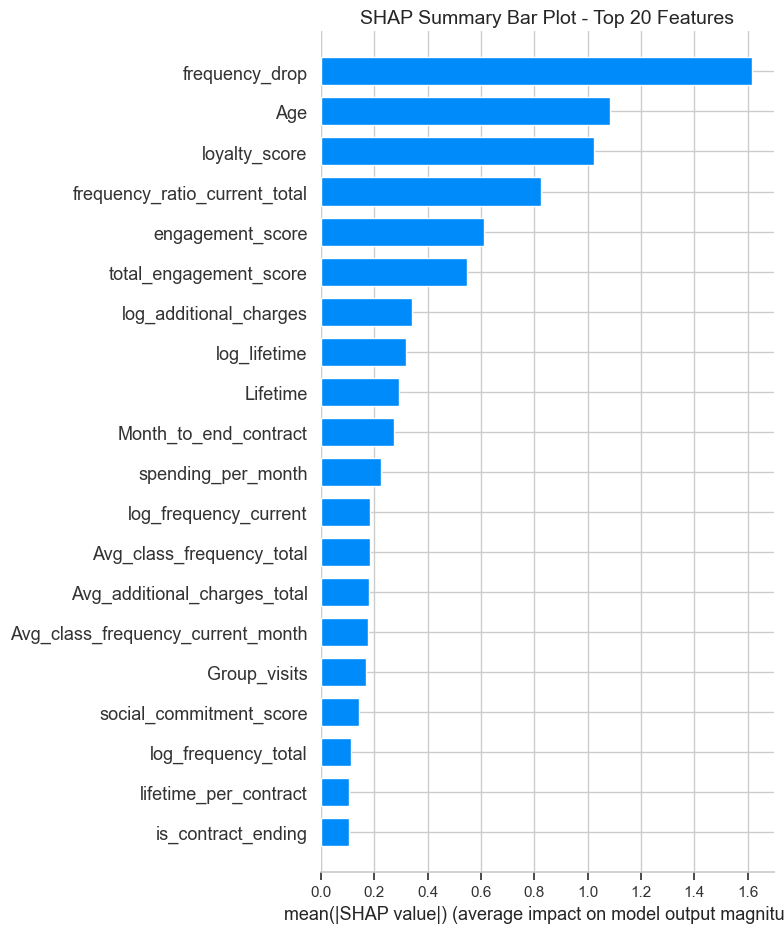

In [26]:
mean_abs_shap = np.abs(shap_values_churn).mean(axis=0)
shap_importance_df = pd.DataFrame({
    "feature": X_test_fe.columns,
    "mean_abs_shap": mean_abs_shap,
}).sort_values("mean_abs_shap", ascending=False)

shap_importance_path = REPORTS_DIR / "shap_feature_importance.csv"
shap_importance_df.to_csv(shap_importance_path, index=False)
print(f"Saved SHAP feature importance to: {shap_importance_path}")
display(shap_importance_df.head(20))

plt.figure(figsize=(10, 8))
top20_shap = shap_importance_df.head(20).sort_values("mean_abs_shap", ascending=True)
sns.barplot(data=top20_shap, x="mean_abs_shap", y="feature", color="#E15759")
plt.title("Top 20 Global SHAP Importance")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_global_importance_top20.png", dpi=150, bbox_inches="tight")
plt.show()

if SHAP_AVAILABLE:
    try:
        shap.summary_plot(shap_values_churn, X_test_fe, plot_type="bar", show=False, max_display=20)
        plt.title("SHAP Summary Bar Plot - Top 20 Features")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "shap_summary_bar_top20.png", dpi=150, bbox_inches="tight")
        plt.show()
    except Exception as exc:
        print(f"SHAP bar summary plot skipped: {exc}")


# 11. SHAP Summary Plot

Cách đọc SHAP summary plot:

- Trục y: feature, sắp xếp theo importance.
- Trục x: SHAP value.
- SHAP > 0: feature làm tăng khả năng churn.
- SHAP < 0: feature làm giảm khả năng churn.
- Màu đỏ: giá trị feature cao.
- Màu xanh: giá trị feature thấp.

Business interpretation kỳ vọng:

- Nếu `frequency_drop` cao có SHAP dương, attendance giảm làm tăng churn.
- Nếu `engagement_score` cao có SHAP âm, engagement tốt làm giảm churn.
- Nếu `contract_remaining_ratio` thấp có SHAP dương, gần hết hợp đồng làm tăng churn.


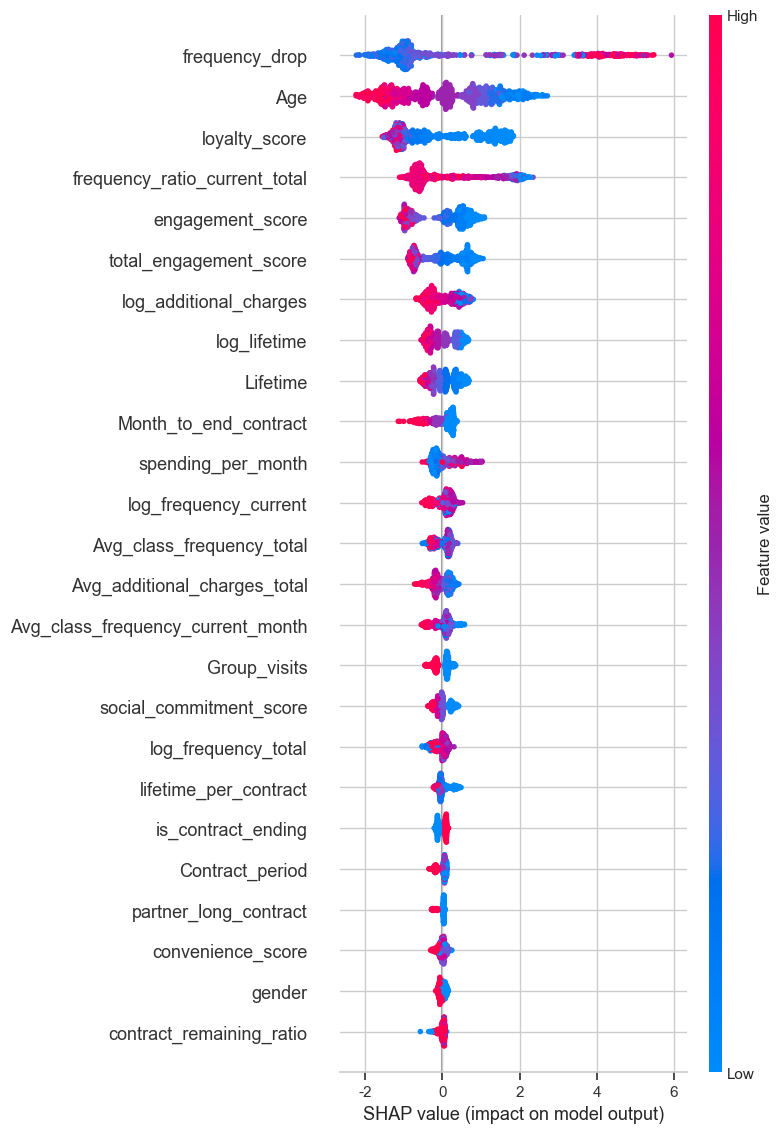

In [27]:
if SHAP_AVAILABLE:
    try:
        shap.summary_plot(shap_values_churn, X_test_fe, feature_names=X_test_fe.columns, show=False, max_display=25)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "shap_summary_plot.png", dpi=150, bbox_inches="tight")
        plt.show()
    except Exception as exc:
        print(f"SHAP summary plot skipped: {exc}")
else:
    print("SHAP is not available. Summary plot skipped.")


# 12. SHAP Dependence Plots

Dependence plots giúp xem feature value thay đổi thì SHAP value thay đổi như thế nào. Notebook ưu tiên SHAP dependence plot, nếu lỗi sẽ fallback sang scatterplot thủ công bằng seaborn/matplotlib.


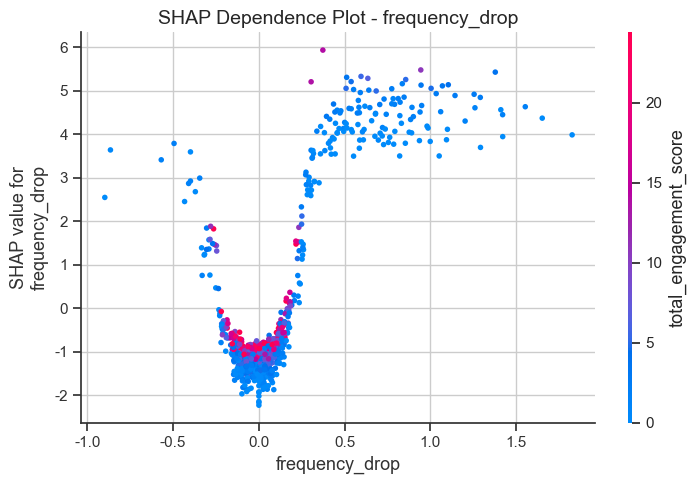

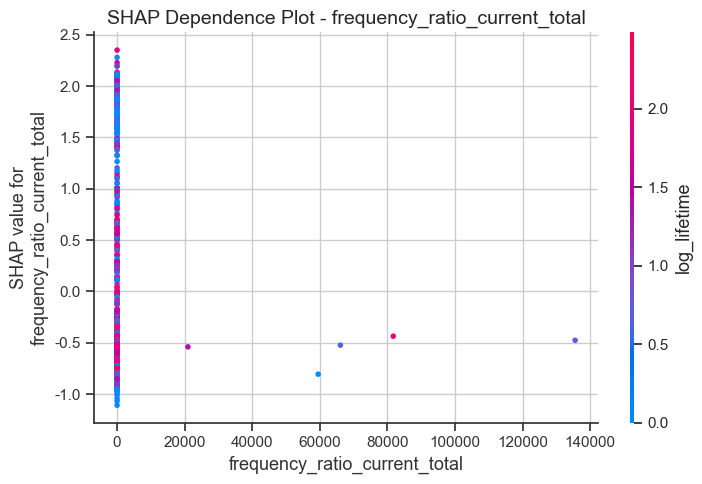

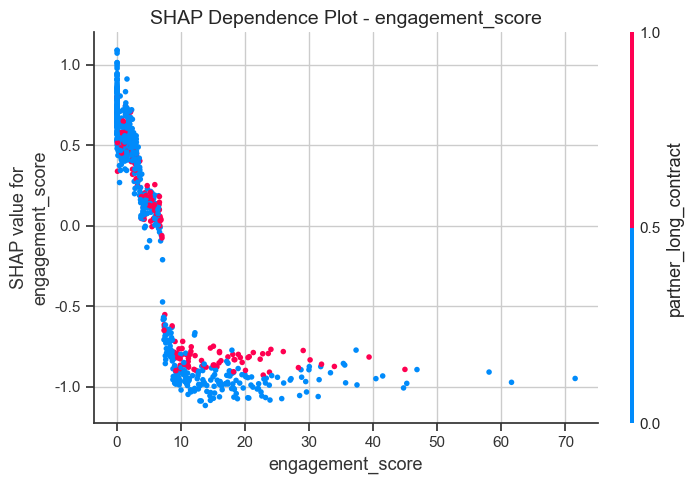

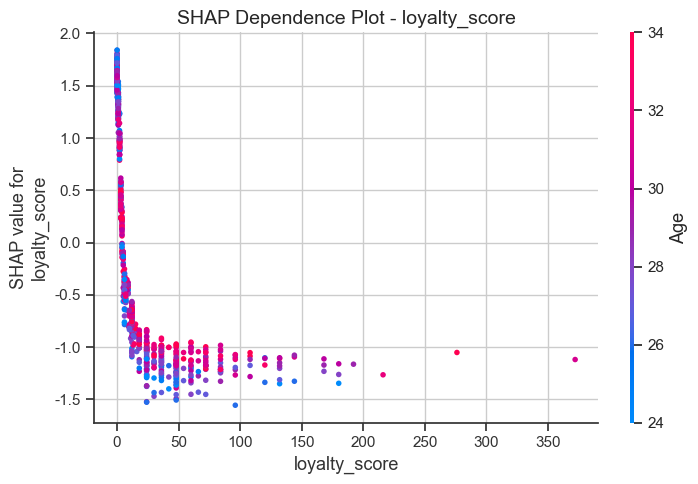

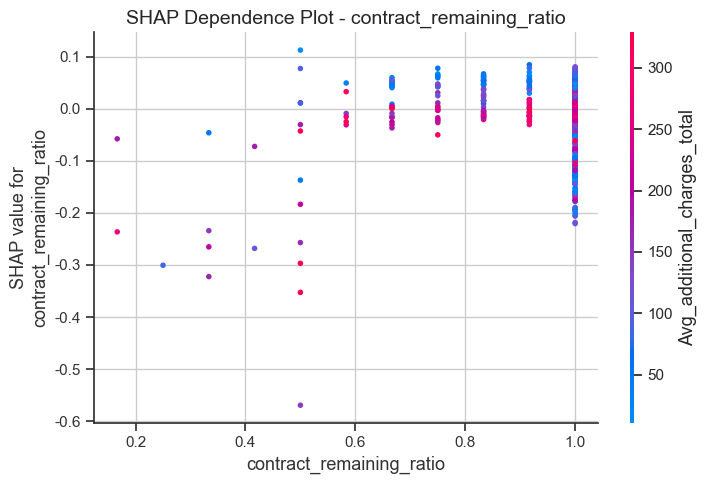

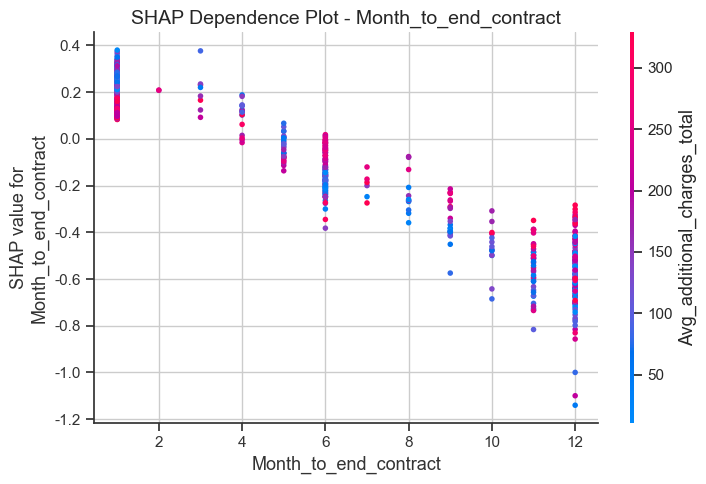

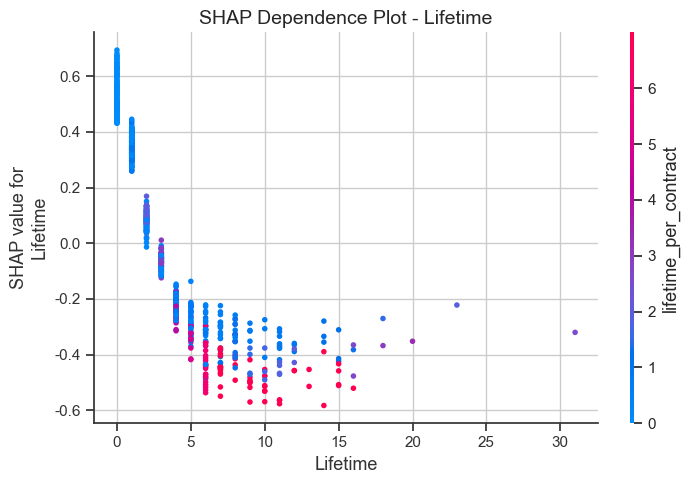

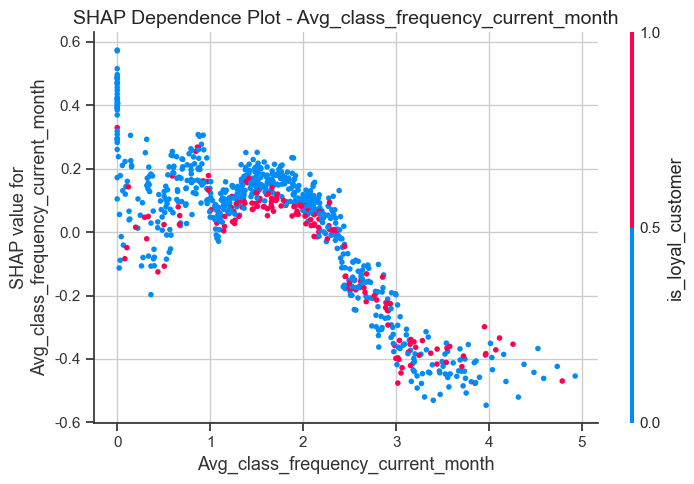

In [28]:
def plot_shap_dependence_manual(feature: str):
    if feature not in X_test_fe.columns:
        print(f"Feature {feature} not found. Skipped.")
        return
    feature_idx = X_test_fe.columns.get_loc(feature)
    plot_df = pd.DataFrame({
        "feature_value": X_test_fe[feature].values,
        "shap_value": shap_values_churn[:, feature_idx],
        "churn_probability": y_proba,
    })
    plt.figure(figsize=(8, 5))
    sns.scatterplot(data=plot_df, x="feature_value", y="shap_value", hue="churn_probability", palette="coolwarm", alpha=0.75)
    plt.axhline(0, color="black", linewidth=1)
    plt.title(f"Manual SHAP Dependence Plot - {feature}")
    plt.xlabel(feature)
    plt.ylabel("SHAP value for churn")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f"shap_dependence_{feature}.png", dpi=150, bbox_inches="tight")
    plt.show()


dependence_features = [
    "frequency_drop",
    "frequency_ratio_current_total",
    "engagement_score",
    "loyalty_score",
    "contract_remaining_ratio",
    "Month_to_end_contract",
    "Lifetime",
    "Avg_class_frequency_current_month",
]

for feature in dependence_features:
    if feature not in X_test_fe.columns:
        print(f"Feature {feature} not available. Skipped.")
        continue
    if SHAP_AVAILABLE:
        try:
            shap.dependence_plot(feature, shap_values_churn, X_test_fe, show=False)
            plt.title(f"SHAP Dependence Plot - {feature}")
            plt.tight_layout()
            plt.savefig(FIGURES_DIR / f"shap_dependence_{feature}.png", dpi=150, bbox_inches="tight")
            plt.show()
        except Exception as exc:
            print(f"SHAP dependence plot failed for {feature}: {exc}. Using manual plot.")
            plot_shap_dependence_manual(feature)
    else:
        plot_shap_dependence_manual(feature)


# 13. Business Driver Analysis

Mapping SHAP drivers sang business meaning giúp retention team hiểu nguyên nhân churn và hành động phù hợp.


In [29]:
business_driver_rows = [
    {
        "feature": "frequency_drop",
        "business_meaning": "Mức giảm tần suất đi tập tháng hiện tại so với trung bình lịch sử.",
        "high_value_interpretation": "Khách đang giảm tương tác với gym.",
        "suggested_action": "Gửi re-engagement campaign, nhắc lịch tập, ưu đãi PT hoặc gọi chăm sóc.",
    },
    {
        "feature": "contract_remaining_ratio",
        "business_meaning": "Tỷ lệ thời gian hợp đồng còn lại.",
        "high_value_interpretation": "Còn nhiều thời gian hợp đồng; low value mới là rủi ro gần hết hạn.",
        "suggested_action": "Chạy renewal campaign trước khi hợp đồng hết hạn.",
    },
    {
        "feature": "engagement_score",
        "business_meaning": "Mức gắn bó tổng hợp dựa trên lifetime và tần suất tháng hiện tại.",
        "high_value_interpretation": "Khách có engagement tốt, thường giảm churn risk.",
        "suggested_action": "Với low engagement, triển khai onboarding, habit-building support hoặc group class.",
    },
    {
        "feature": "loyalty_score",
        "business_meaning": "Mức độ cam kết lâu dài dựa trên lifetime và contract period.",
        "high_value_interpretation": "Khách có mức cam kết cao.",
        "suggested_action": "Với low loyalty, đề xuất loyalty program hoặc ưu đãi gia hạn.",
    },
    {
        "feature": "low_current_activity",
        "business_meaning": "Khách đi tập dưới 1 buổi/tuần trong tháng hiện tại.",
        "high_value_interpretation": "Tần suất thấp, rủi ro churn cao.",
        "suggested_action": "Gửi reminder, free PT trial, hoặc lịch lớp phù hợp.",
    },
    {
        "feature": "is_contract_ending",
        "business_meaning": "Hợp đồng còn tối đa 1 tháng.",
        "high_value_interpretation": "Rủi ro renewal cao.",
        "suggested_action": "Liên hệ trước ngày hết hạn, offer renewal discount.",
    },
    {
        "feature": "far_no_group",
        "business_meaning": "Khách ở xa và không tham gia group visits.",
        "high_value_interpretation": "Thiếu convenience và social commitment.",
        "suggested_action": "Mời tham gia lớp nhóm, cộng đồng hoặc lịch tập thuận tiện.",
    },
]

business_driver_mapping = pd.DataFrame(business_driver_rows)
business_driver_path = REPORTS_DIR / "business_driver_mapping.csv"
business_driver_mapping.to_csv(business_driver_path, index=False)
print(f"Saved business driver mapping to: {business_driver_path}")
display(business_driver_mapping)


Saved business driver mapping to: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\reports\business_driver_mapping.csv


,feature,business_meaning,high_value_interpretation,suggested_action
0,frequency_drop,Mức giảm tần suất đi tập tháng hiện tại so với...,Khách đang giảm tương tác với gym.,"Gửi re-engagement campaign, nhắc lịch tập, ưu ..."
1,contract_remaining_ratio,Tỷ lệ thời gian hợp đồng còn lại.,Còn nhiều thời gian hợp đồng; low value mới là...,Chạy renewal campaign trước khi hợp đồng hết hạn.
2,engagement_score,Mức gắn bó tổng hợp dựa trên lifetime và tần s...,"Khách có engagement tốt, thường giảm churn risk.","Với low engagement, triển khai onboarding, hab..."
3,loyalty_score,Mức độ cam kết lâu dài dựa trên lifetime và co...,Khách có mức cam kết cao.,"Với low loyalty, đề xuất loyalty program hoặc ..."
4,low_current_activity,Khách đi tập dưới 1 buổi/tuần trong tháng hiện...,"Tần suất thấp, rủi ro churn cao.","Gửi reminder, free PT trial, hoặc lịch lớp phù..."
5,is_contract_ending,Hợp đồng còn tối đa 1 tháng.,Rủi ro renewal cao.,"Liên hệ trước ngày hết hạn, offer renewal disc..."
6,far_no_group,Khách ở xa và không tham gia group visits.,Thiếu convenience và social commitment.,"Mời tham gia lớp nhóm, cộng đồng hoặc lịch tập..."


# 14. Local Explainability: High-Risk Customers

Phân tích local explanation cho top 5 khách hàng có churn probability cao nhất. Với mỗi khách, ta xem profile, predicted probability, actual label, top positive SHAP contributors và top negative SHAP contributors.


,original_index,y_true,y_pred,churn_probability
3533,3533,1,1,1.0000
221,221,1,1,1.0000
3205,3205,1,1,1.0000
1821,1821,1,1,1.0000
3870,3870,1,1,1.0000


Customer index: 3533
Predicted churn probability: 1.0000
Predicted label: 1
Actual label: 1
Customer profile:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,frequency_drop,frequency_ratio_current_total,low_current_activity,high_current_activity,engagement_score,total_engagement_score,contract_remaining_ratio,is_contract_ending,is_short_contract,is_long_contract,renewal_pressure_score,is_new_customer,is_loyal_customer,lifetime_per_contract,loyalty_score,spending_per_month,high_spending,low_spending,convenience_score,social_commitment_score,far_no_group,no_contact_info,new_low_activity,ending_low_activity,far_low_activity,short_contract_low_activity,no_group_low_activity,partner_long_contract,promo_group,log_lifetime,log_additional_charges,log_frequency_current,log_frequency_total
3533,1,1,0,0,1,1,0,25,72.2544,1.0000,0,1.9579,1.2385,0.7194,0.6326,0,0,0.0000,0.0000,1.0000,1,1,0,1,1,0,0.0000,0,72.2544,0,0,2,0,0,0,0,0,0,0,0,0,0,0.0000,4.2939,0.8058,1.0845


Top positive SHAP contributors:


,feature,feature_value,shap_value,direction
13,frequency_drop,0.7194,3.9598,increases churn risk
7,Age,25.0000,1.7320,increases churn risk
14,frequency_ratio_current_total,0.6326,1.7160,increases churn risk
27,loyalty_score,0.0000,1.6131,increases churn risk
18,total_engagement_score,0.0000,0.6478,increases churn risk


Top negative SHAP contributors:


,feature,feature_value,shap_value,direction
0,gender,1.0000,-0.0787,decreases churn risk
38,short_contract_low_activity,0.0000,-0.0194,decreases churn risk
35,new_low_activity,0.0000,-0.0165,decreases churn risk
2,Partner,0.0000,-0.0149,decreases churn risk
39,no_group_low_activity,0.0000,-0.0128,decreases churn risk


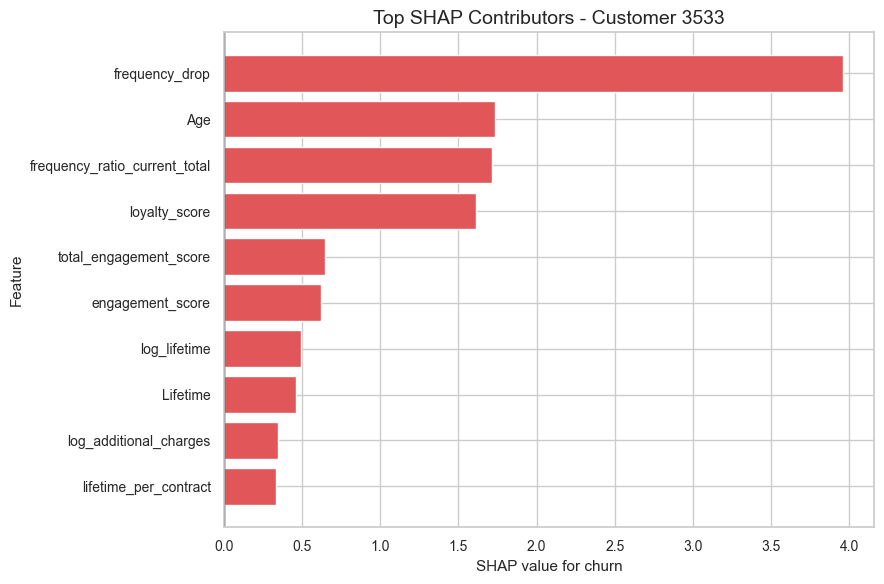

Customer index: 221
Predicted churn probability: 1.0000
Predicted label: 1
Actual label: 1
Customer profile:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,frequency_drop,frequency_ratio_current_total,low_current_activity,high_current_activity,engagement_score,total_engagement_score,contract_remaining_ratio,is_contract_ending,is_short_contract,is_long_contract,renewal_pressure_score,is_new_customer,is_loyal_customer,lifetime_per_contract,loyalty_score,spending_per_month,high_spending,low_spending,convenience_score,social_commitment_score,far_no_group,no_contact_info,new_low_activity,ending_low_activity,far_low_activity,short_contract_low_activity,no_group_low_activity,partner_long_contract,promo_group,log_lifetime,log_additional_charges,log_frequency_current,log_frequency_total
221,1,1,0,0,1,1,1,27,33.3490,1.0000,0,1.8331,0.0064,1.8267,0.0035,1,0,0.0000,0.0000,1.0000,1,1,0,1,1,0,0.0000,0,33.3490,0,1,2,1,0,0,1,1,0,1,0,0,0,0.0000,3.5366,0.0064,1.0414


Top positive SHAP contributors:


,feature,feature_value,shap_value,direction
13,frequency_drop,1.8267,3.9852,increases churn risk
14,frequency_ratio_current_total,0.0035,2.0023,increases churn risk
27,loyalty_score,0.0000,1.5282,increases churn risk
7,Age,27.0000,1.1915,increases churn risk
17,engagement_score,0.0000,0.7049,increases churn risk


Top negative SHAP contributors:


,feature,feature_value,shap_value,direction
6,Group_visits,1.0000,-0.2025,decreases churn risk
0,gender,1.0000,-0.0688,decreases churn risk
28,spending_per_month,33.3490,-0.0231,decreases churn risk
1,Near_Location,1.0000,-0.0139,decreases churn risk
32,social_commitment_score,1.0000,-0.0117,decreases churn risk


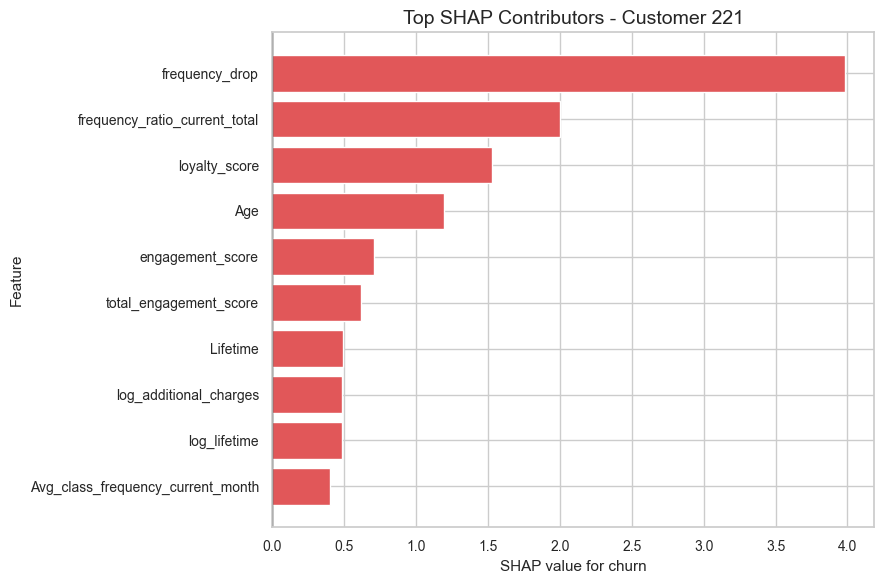

Customer index: 3205
Predicted churn probability: 1.0000
Predicted label: 1
Actual label: 1
Customer profile:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,frequency_drop,frequency_ratio_current_total,low_current_activity,high_current_activity,engagement_score,total_engagement_score,contract_remaining_ratio,is_contract_ending,is_short_contract,is_long_contract,renewal_pressure_score,is_new_customer,is_loyal_customer,lifetime_per_contract,loyalty_score,spending_per_month,high_spending,low_spending,convenience_score,social_commitment_score,far_no_group,no_contact_info,new_low_activity,ending_low_activity,far_low_activity,short_contract_low_activity,no_group_low_activity,partner_long_contract,promo_group,log_lifetime,log_additional_charges,log_frequency_current,log_frequency_total
3205,1,1,0,0,1,1,0,23,87.0473,1.0000,0,2.0477,1.1115,0.9362,0.5428,0,0,0.0000,0.0000,1.0000,1,1,0,1,1,0,0.0000,0,87.0473,0,0,2,0,0,0,0,0,0,0,0,0,0,0.0000,4.4779,0.7474,1.1144


Top positive SHAP contributors:


,feature,feature_value,shap_value,direction
13,frequency_drop,0.9362,3.8527,increases churn risk
7,Age,23.0000,1.7927,increases churn risk
14,frequency_ratio_current_total,0.5428,1.7125,increases churn risk
27,loyalty_score,0.0000,1.6053,increases churn risk
18,total_engagement_score,0.0000,0.6157,increases churn risk


Top negative SHAP contributors:


,feature,feature_value,shap_value,direction
0,gender,1.0000,-0.0691,decreases churn risk
38,short_contract_low_activity,0.0000,-0.0354,decreases churn risk
39,no_group_low_activity,0.0000,-0.0128,decreases churn risk
35,new_low_activity,0.0000,-0.0109,decreases churn risk
36,ending_low_activity,0.0000,-0.0108,decreases churn risk


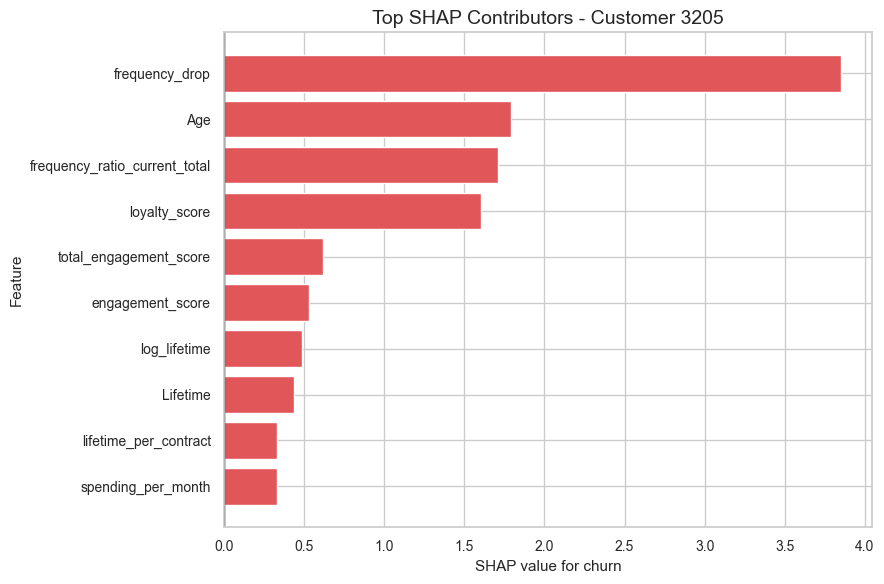

Customer index: 1821
Predicted churn probability: 1.0000
Predicted label: 1
Actual label: 1
Customer profile:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,frequency_drop,frequency_ratio_current_total,low_current_activity,high_current_activity,engagement_score,total_engagement_score,contract_remaining_ratio,is_contract_ending,is_short_contract,is_long_contract,renewal_pressure_score,is_new_customer,is_loyal_customer,lifetime_per_contract,loyalty_score,spending_per_month,high_spending,low_spending,convenience_score,social_commitment_score,far_no_group,no_contact_info,new_low_activity,ending_low_activity,far_low_activity,short_contract_low_activity,no_group_low_activity,partner_long_contract,promo_group,log_lifetime,log_additional_charges,log_frequency_current,log_frequency_total
1821,0,1,0,0,1,1,0,25,237.2225,1.0000,0,1.8055,1.0983,0.7071,0.6083,0,0,0.0000,0.0000,1.0000,1,1,0,1,1,0,0.0000,0,237.2225,1,0,2,0,0,0,0,0,0,0,0,0,0,0.0000,5.4732,0.7411,1.0316


Top positive SHAP contributors:


,feature,feature_value,shap_value,direction
13,frequency_drop,0.7071,4.0245,increases churn risk
14,frequency_ratio_current_total,0.6083,1.8848,increases churn risk
7,Age,25.0000,1.7328,increases churn risk
27,loyalty_score,0.0000,1.5954,increases churn risk
18,total_engagement_score,0.0000,0.6805,increases churn risk


Top negative SHAP contributors:


,feature,feature_value,shap_value,direction
43,log_additional_charges,5.4732,-0.3770,decreases churn risk
8,Avg_additional_charges_total,237.2225,-0.1861,decreases churn risk
38,short_contract_low_activity,0.0000,-0.0300,decreases churn risk
35,new_low_activity,0.0000,-0.0137,decreases churn risk
39,no_group_low_activity,0.0000,-0.0135,decreases churn risk


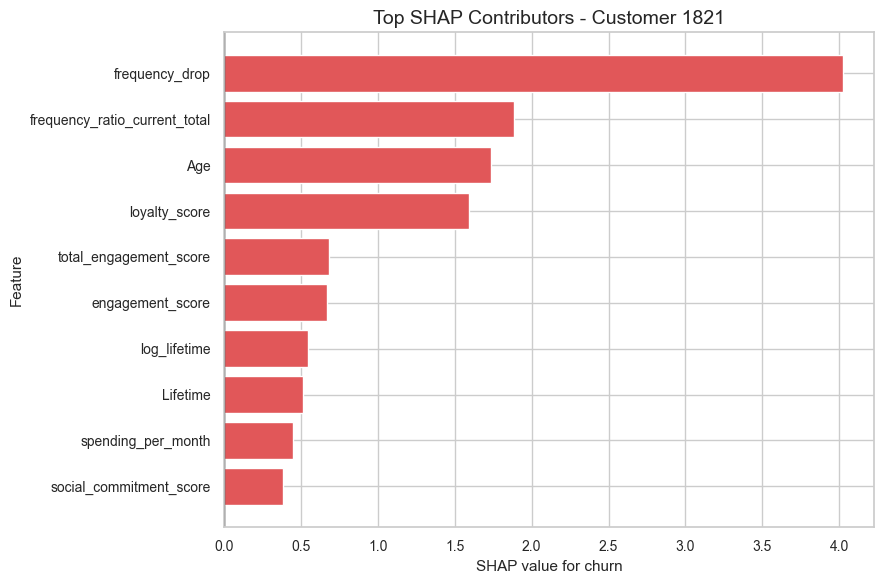

Customer index: 3870
Predicted churn probability: 1.0000
Predicted label: 1
Actual label: 1
Customer profile:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,frequency_drop,frequency_ratio_current_total,low_current_activity,high_current_activity,engagement_score,total_engagement_score,contract_remaining_ratio,is_contract_ending,is_short_contract,is_long_contract,renewal_pressure_score,is_new_customer,is_loyal_customer,lifetime_per_contract,loyalty_score,spending_per_month,high_spending,low_spending,convenience_score,social_commitment_score,far_no_group,no_contact_info,new_low_activity,ending_low_activity,far_low_activity,short_contract_low_activity,no_group_low_activity,partner_long_contract,promo_group,log_lifetime,log_additional_charges,log_frequency_current,log_frequency_total
3870,0,1,0,0,0,1,1,24,85.7672,1.0000,0,0.7861,0.0000,0.7861,0.0000,1,0,0.0000,0.0000,1.0000,1,1,0,1,1,0,0.0000,0,85.7672,0,0,1,1,0,1,1,1,0,1,0,0,0,0.0000,4.4632,0.0000,0.5801


Top positive SHAP contributors:


,feature,feature_value,shap_value,direction
13,frequency_drop,0.7861,3.7710,increases churn risk
14,frequency_ratio_current_total,0.0000,1.9219,increases churn risk
7,Age,24.0000,1.5758,increases churn risk
27,loyalty_score,0.0000,1.5544,increases churn risk
18,total_engagement_score,0.0000,0.6557,increases churn risk


Top negative SHAP contributors:


,feature,feature_value,shap_value,direction
6,Group_visits,1.0000,-0.2563,decreases churn risk
45,log_frequency_total,0.5801,-0.0952,decreases churn risk
4,Phone,0.0000,-0.0791,decreases churn risk
39,no_group_low_activity,0.0000,-0.0274,decreases churn risk
1,Near_Location,1.0000,-0.0083,decreases churn risk


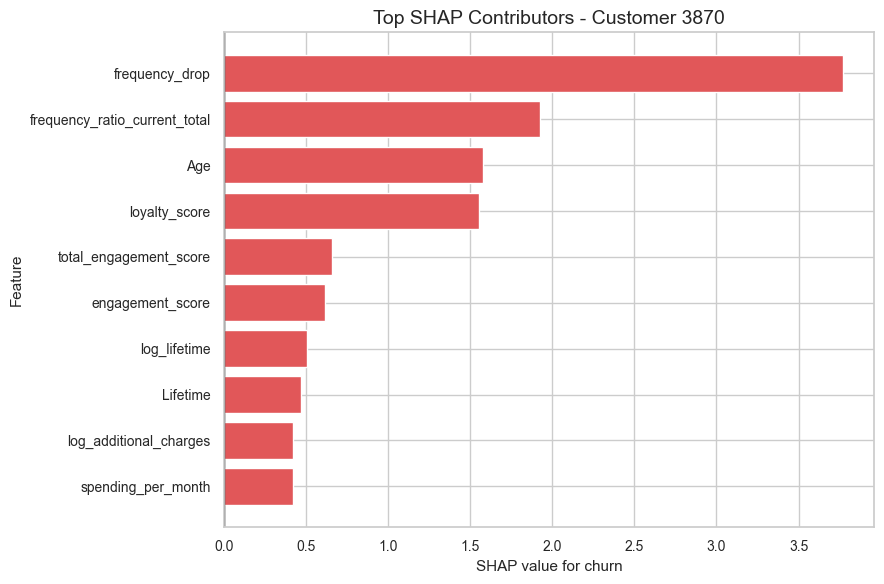

In [30]:
test_predictions = pd.DataFrame({
    "original_index": X_test_fe.index,
    "y_true": y_test.values,
    "y_pred": y_pred,
    "churn_probability": y_proba,
}, index=X_test_fe.index).sort_values("churn_probability", ascending=False)

def customer_shap_table(customer_index, top_n=5):
    if customer_index not in X_test_fe.index:
        raise KeyError(f"customer_index {customer_index} not found in X_test_fe index.")
    pos = X_test_fe.index.get_loc(customer_index)
    values = X_test_fe.loc[customer_index]
    shap_row = shap_values_churn[pos]
    explanation = pd.DataFrame({
        "feature": X_test_fe.columns,
        "feature_value": values.values,
        "shap_value": shap_row,
    })
    explanation["direction"] = np.where(explanation["shap_value"] > 0, "increases churn risk", "decreases churn risk")
    explanation["abs_shap"] = explanation["shap_value"].abs()
    return explanation.sort_values("abs_shap", ascending=False)


def explain_customer(customer_index, top_n=5, plot=True):
    pred_row = test_predictions.loc[customer_index]
    print("=" * 80)
    print(f"Customer index: {customer_index}")
    print(f"Predicted churn probability: {pred_row['churn_probability']:.4f}")
    print(f"Predicted label: {int(pred_row['y_pred'])}")
    print(f"Actual label: {int(pred_row['y_true'])}")
    print("Customer profile:")
    display(X_test_fe.loc[[customer_index]])

    explanation = customer_shap_table(customer_index, top_n=top_n)
    positive = explanation[explanation["shap_value"] > 0].head(top_n)
    negative = explanation[explanation["shap_value"] < 0].head(top_n)
    print("Top positive SHAP contributors:")
    display(positive[["feature", "feature_value", "shap_value", "direction"]])
    print("Top negative SHAP contributors:")
    display(negative[["feature", "feature_value", "shap_value", "direction"]])

    if plot:
        top_plot = explanation.head(top_n * 2).sort_values("shap_value")
        plt.figure(figsize=(9, 6))
        colors = np.where(top_plot["shap_value"] > 0, "#E15759", "#4C78A8")
        plt.barh(top_plot["feature"], top_plot["shap_value"], color=colors)
        plt.axvline(0, color="black", linewidth=1)
        plt.title(f"Top SHAP Contributors - Customer {customer_index}")
        plt.xlabel("SHAP value for churn")
        plt.ylabel("Feature")
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / f"shap_customer_{customer_index}_contributors.png", dpi=150, bbox_inches="tight")
        plt.show()
    return explanation

high_risk_customers = test_predictions.head(5)
display(high_risk_customers)
high_risk_explanations = {}
for customer_index in high_risk_customers.index:
    high_risk_explanations[customer_index] = explain_customer(customer_index, top_n=5, plot=True)


# 15. Local Explainability: Low-Risk Customers

Phân tích 5 khách hàng có churn probability thấp nhất để hiểu vì sao model tin rằng họ ít có khả năng churn.


,original_index,y_true,y_pred,churn_probability
277,277,0,0,0.0000
2790,2790,0,0,0.0000
2851,2851,0,0,0.0000
3755,3755,0,0,0.0000
782,782,0,0,0.0000


Customer index: 277
Predicted churn probability: 0.0000
Predicted label: 0
Actual label: 0
Customer profile:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,frequency_drop,frequency_ratio_current_total,low_current_activity,high_current_activity,engagement_score,total_engagement_score,contract_remaining_ratio,is_contract_ending,is_short_contract,is_long_contract,renewal_pressure_score,is_new_customer,is_loyal_customer,lifetime_per_contract,loyalty_score,spending_per_month,high_spending,low_spending,convenience_score,social_commitment_score,far_no_group,no_contact_info,new_low_activity,ending_low_activity,far_low_activity,short_contract_low_activity,no_group_low_activity,partner_long_contract,promo_group,log_lifetime,log_additional_charges,log_frequency_current,log_frequency_total
277,0,1,1,1,1,12,1,35,302.8785,9.0000,4,4.6620,4.7331,-0.0711,1.0153,0,1,18.9322,18.6478,0.7500,0,0,1,0,0,0,0.3333,48,60.5757,1,0,4,3,0,0,0,0,0,0,0,1,1,1.6094,5.7166,1.7462,1.7338


Top positive SHAP contributors:


,feature,feature_value,shap_value,direction
28,spending_per_month,60.5757,0.3237,increases churn risk
2,Partner,1.0000,0.0490,increases churn risk
0,gender,0.0000,0.0273,increases churn risk
26,lifetime_per_contract,0.3333,0.0240,increases churn risk
34,no_contact_info,0.0000,0.0149,increases churn risk


Top negative SHAP contributors:


,feature,feature_value,shap_value,direction
7,Age,35.0000,-1.4339,decreases churn risk
13,frequency_drop,-0.0711,-0.9867,decreases churn risk
27,loyalty_score,48.0000,-0.9701,decreases churn risk
17,engagement_score,18.9322,-0.7987,decreases churn risk
18,total_engagement_score,18.6478,-0.7144,decreases churn risk


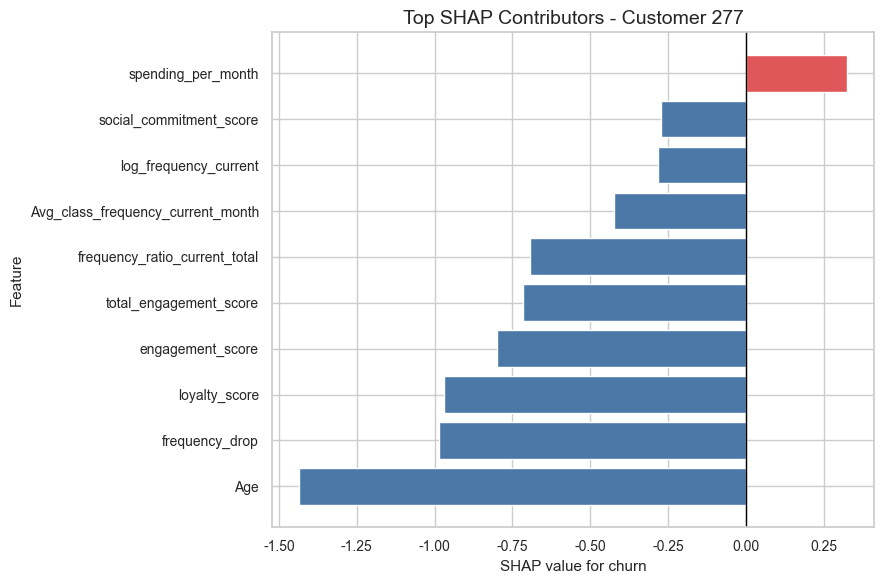

Customer index: 2790
Predicted churn probability: 0.0000
Predicted label: 0
Actual label: 0
Customer profile:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,frequency_drop,frequency_ratio_current_total,low_current_activity,high_current_activity,engagement_score,total_engagement_score,contract_remaining_ratio,is_contract_ending,is_short_contract,is_long_contract,renewal_pressure_score,is_new_customer,is_loyal_customer,lifetime_per_contract,loyalty_score,spending_per_month,high_spending,low_spending,convenience_score,social_commitment_score,far_no_group,no_contact_info,new_low_activity,ending_low_activity,far_low_activity,short_contract_low_activity,no_group_low_activity,partner_long_contract,promo_group,log_lifetime,log_additional_charges,log_frequency_current,log_frequency_total
2790,1,1,1,1,0,6,1,32,255.6230,6.0000,11,3.0307,3.0293,0.0014,0.9995,0,1,33.3224,33.3380,1.0000,0,0,0,0,0,1,1.8333,66,21.3019,1,0,3,3,0,1,0,0,0,0,0,0,1,2.4849,5.5476,1.3936,1.3939


Top positive SHAP contributors:


,feature,feature_value,shap_value,direction
2,Partner,1.0000,0.0552,increases churn risk
40,partner_long_contract,0.0000,0.0309,increases churn risk
5,Contract_period,6.0000,0.0171,increases churn risk
22,is_long_contract,0.0000,0.0054,increases churn risk
33,far_no_group,0.0000,0.0007,increases churn risk


Top negative SHAP contributors:


,feature,feature_value,shap_value,direction
7,Age,32.0000,-1.1377,decreases churn risk
27,loyalty_score,66.0000,-1.0435,decreases churn risk
17,engagement_score,33.3224,-0.9129,decreases churn risk
13,frequency_drop,0.0014,-0.8482,decreases churn risk
18,total_engagement_score,33.3380,-0.7602,decreases churn risk


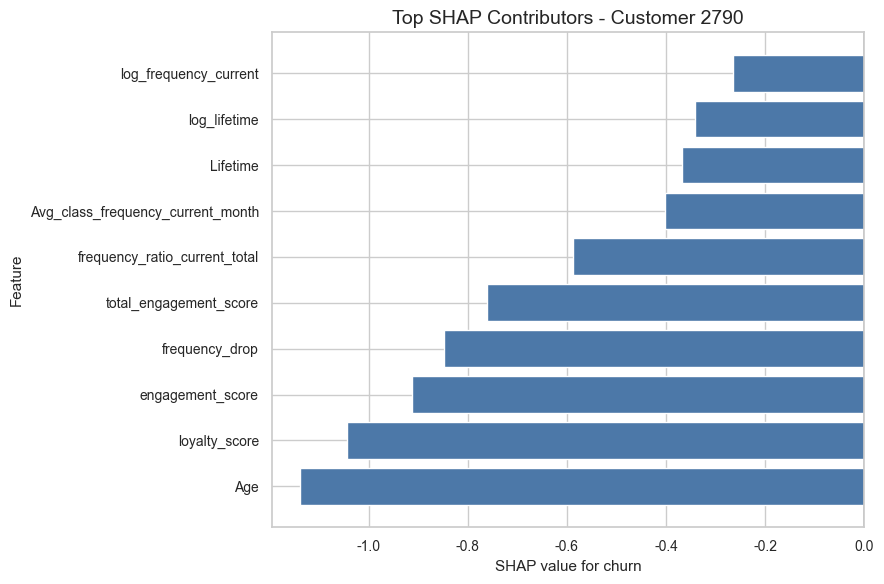

Customer index: 2851
Predicted churn probability: 0.0000
Predicted label: 0
Actual label: 0
Customer profile:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,frequency_drop,frequency_ratio_current_total,low_current_activity,high_current_activity,engagement_score,total_engagement_score,contract_remaining_ratio,is_contract_ending,is_short_contract,is_long_contract,renewal_pressure_score,is_new_customer,is_loyal_customer,lifetime_per_contract,loyalty_score,spending_per_month,high_spending,low_spending,convenience_score,social_commitment_score,far_no_group,no_contact_info,new_low_activity,ending_low_activity,far_low_activity,short_contract_low_activity,no_group_low_activity,partner_long_contract,promo_group,log_lifetime,log_additional_charges,log_frequency_current,log_frequency_total
2851,1,1,1,1,1,12,1,31,167.1006,12.0000,5,3.1355,3.1973,-0.0617,1.0197,0,1,15.9863,15.6776,1.0000,0,0,1,0,0,0,0.4167,60,27.8501,0,0,4,3,0,0,0,0,0,0,0,1,1,1.7918,5.1246,1.4344,1.4196


Top positive SHAP contributors:


,feature,feature_value,shap_value,direction
2,Partner,1.0000,0.0568,increases churn risk
19,contract_remaining_ratio,1.0000,0.0510,increases churn risk
34,no_contact_info,0.0000,0.0105,increases churn risk
25,is_loyal_customer,0.0000,0.0089,increases churn risk
33,far_no_group,0.0000,0.0062,increases churn risk


Top negative SHAP contributors:


,feature,feature_value,shap_value,direction
27,loyalty_score,60.0000,-1.0165,decreases churn risk
13,frequency_drop,-0.0617,-0.8480,decreases churn risk
7,Age,31.0000,-0.7847,decreases churn risk
17,engagement_score,15.9863,-0.7811,decreases churn risk
14,frequency_ratio_current_total,1.0197,-0.7011,decreases churn risk


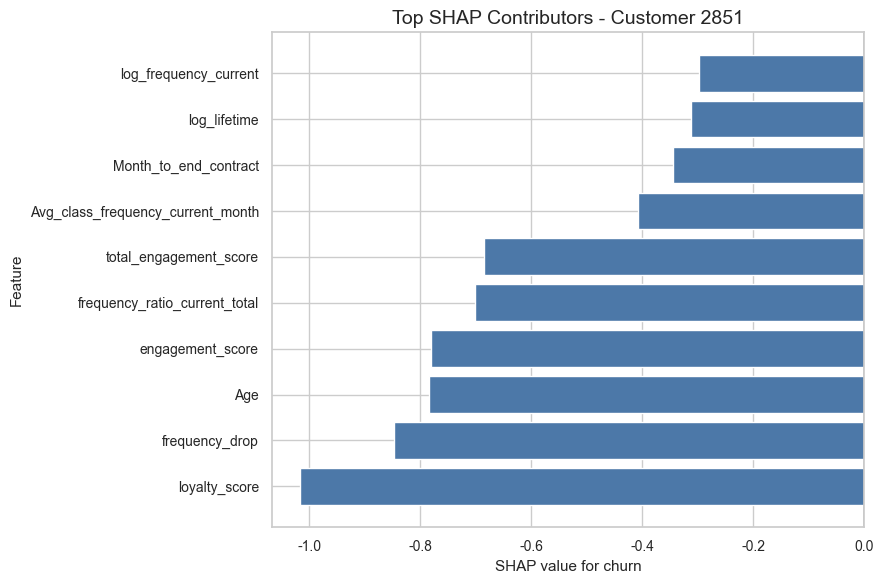

Customer index: 3755
Predicted churn probability: 0.0000
Predicted label: 0
Actual label: 0
Customer profile:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,frequency_drop,frequency_ratio_current_total,low_current_activity,high_current_activity,engagement_score,total_engagement_score,contract_remaining_ratio,is_contract_ending,is_short_contract,is_long_contract,renewal_pressure_score,is_new_customer,is_loyal_customer,lifetime_per_contract,loyalty_score,spending_per_month,high_spending,low_spending,convenience_score,social_commitment_score,far_no_group,no_contact_info,new_low_activity,ending_low_activity,far_low_activity,short_contract_low_activity,no_group_low_activity,partner_long_contract,promo_group,log_lifetime,log_additional_charges,log_frequency_current,log_frequency_total
3755,1,1,1,1,1,12,0,31,193.2639,11.0000,7,3.1845,3.2483,-0.0638,1.0200,0,1,22.7379,22.2914,0.9167,0,0,1,0,0,1,0.5833,84,24.1580,0,0,4,2,0,0,0,0,0,0,0,1,0,2.0794,5.2692,1.4465,1.4314


Top positive SHAP contributors:


,feature,feature_value,shap_value,direction
6,Group_visits,0.0000,0.0989,increases churn risk
2,Partner,1.0000,0.0560,increases churn risk
41,promo_group,0.0000,0.0226,increases churn risk
34,no_contact_info,0.0000,0.0136,increases churn risk
33,far_no_group,0.0000,0.0069,increases churn risk


Top negative SHAP contributors:


,feature,feature_value,shap_value,direction
27,loyalty_score,84.0000,-1.0220,decreases churn risk
7,Age,31.0000,-0.8977,decreases churn risk
13,frequency_drop,-0.0638,-0.8830,decreases churn risk
17,engagement_score,22.7379,-0.7948,decreases churn risk
18,total_engagement_score,22.2914,-0.7287,decreases churn risk


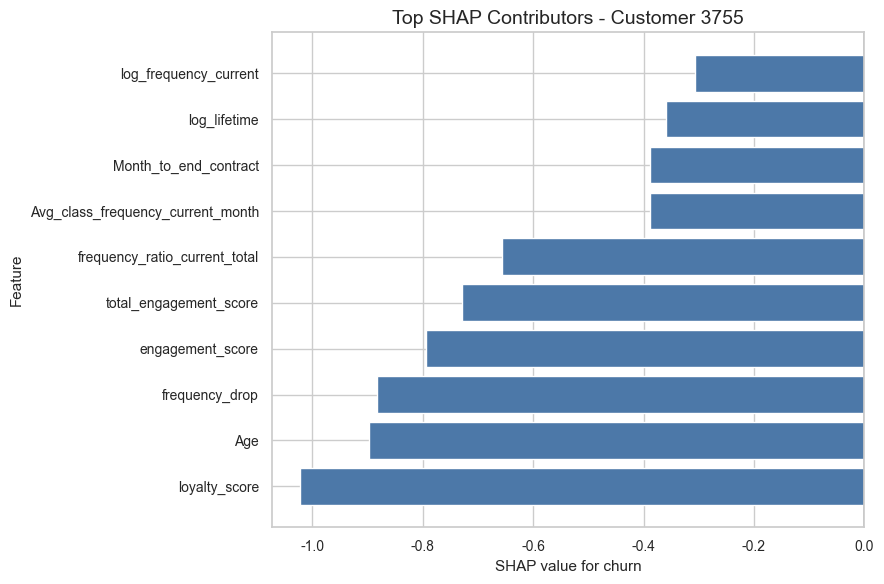

Customer index: 782
Predicted churn probability: 0.0000
Predicted label: 0
Actual label: 0
Customer profile:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,frequency_drop,frequency_ratio_current_total,low_current_activity,high_current_activity,engagement_score,total_engagement_score,contract_remaining_ratio,is_contract_ending,is_short_contract,is_long_contract,renewal_pressure_score,is_new_customer,is_loyal_customer,lifetime_per_contract,loyalty_score,spending_per_month,high_spending,low_spending,convenience_score,social_commitment_score,far_no_group,no_contact_info,new_low_activity,ending_low_activity,far_low_activity,short_contract_low_activity,no_group_low_activity,partner_long_contract,promo_group,log_lifetime,log_additional_charges,log_frequency_current,log_frequency_total
782,1,1,0,0,1,12,1,31,94.3816,12.0000,5,3.3161,3.4648,-0.1488,1.0449,0,1,17.3242,16.5804,1.0000,0,0,1,0,0,0,0.4167,60,15.7303,0,0,2,1,0,0,0,0,0,0,0,0,0,1.7918,4.5579,1.4962,1.4623


Top positive SHAP contributors:


,feature,feature_value,shap_value,direction
43,log_additional_charges,4.5579,0.0707,increases churn risk
31,convenience_score,2.0000,0.0443,increases churn risk
3,Promo_friends,0.0000,0.0325,increases churn risk
8,Avg_additional_charges_total,94.3816,0.0300,increases churn risk
40,partner_long_contract,0.0000,0.0249,increases churn risk


Top negative SHAP contributors:


,feature,feature_value,shap_value,direction
27,loyalty_score,60.0000,-1.1266,decreases churn risk
7,Age,31.0000,-0.8936,decreases churn risk
17,engagement_score,17.3242,-0.8539,decreases churn risk
18,total_engagement_score,16.5804,-0.7328,decreases churn risk
13,frequency_drop,-0.1488,-0.6906,decreases churn risk


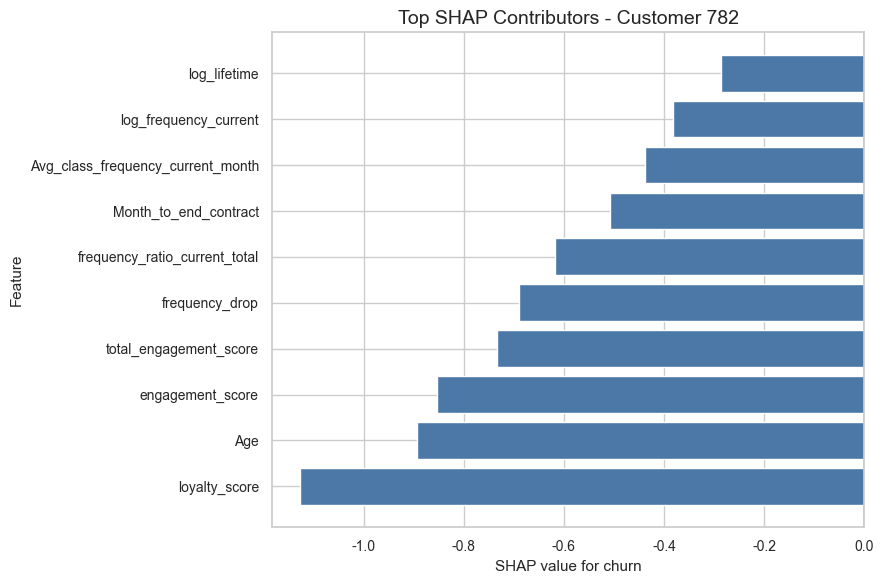

In [31]:
low_risk_customers = test_predictions.sort_values("churn_probability", ascending=True).head(5)
display(low_risk_customers)
low_risk_explanations = {}
for customer_index in low_risk_customers.index:
    low_risk_explanations[customer_index] = explain_customer(customer_index, top_n=5, plot=True)


# 16. Misclassification Analysis

Phân tích True Positive, True Negative, False Positive và False Negative. False Negative đặc biệt nguy hiểm vì đó là khách thực tế churn nhưng model không cảnh báo. False Positive cũng quan trọng vì gây chi phí retention không cần thiết.


In [32]:
analysis_df = test_predictions.copy()
analysis_df["error_group"] = np.select(
    [
        (analysis_df["y_true"] == 1) & (analysis_df["y_pred"] == 1),
        (analysis_df["y_true"] == 0) & (analysis_df["y_pred"] == 0),
        (analysis_df["y_true"] == 0) & (analysis_df["y_pred"] == 1),
        (analysis_df["y_true"] == 1) & (analysis_df["y_pred"] == 0),
    ],
    ["True Positive", "True Negative", "False Positive", "False Negative"],
    default="Unknown",
)

group_summary = analysis_df.groupby("error_group").agg(
    customer_count=("y_true", "count"),
    avg_churn_probability=("churn_probability", "mean"),
    actual_churn_rate=("y_true", "mean"),
).reset_index().sort_values("customer_count", ascending=False)
display(group_summary)

def average_shap_by_group(group_name, top_n=10):
    idx = analysis_df[analysis_df["error_group"] == group_name].index
    if len(idx) == 0:
        return pd.DataFrame(columns=["feature", "mean_shap", "mean_abs_shap"])
    positions = [X_test_fe.index.get_loc(i) for i in idx]
    group_shap = shap_values_churn[positions]
    out = pd.DataFrame({
        "feature": X_test_fe.columns,
        "mean_shap": group_shap.mean(axis=0),
        "mean_abs_shap": np.abs(group_shap).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False).head(top_n)
    return out

for group_name in ["True Positive", "True Negative", "False Positive", "False Negative"]:
    print("=" * 80)
    print(group_name)
    display(average_shap_by_group(group_name, top_n=10))

false_negative_cases = analysis_df[analysis_df["error_group"] == "False Negative"].sort_values("churn_probability", ascending=False).head(3)
print("False Negative sample cases:")
display(false_negative_cases)
for customer_index in false_negative_cases.index:
    explain_customer(customer_index, top_n=5, plot=False)


,error_group,customer_count,avg_churn_probability,actual_churn_rate
2,True Negative,578,0.0183,0.0000
3,True Positive,188,0.9838,1.0000
0,False Negative,24,0.2099,1.0000
1,False Positive,10,0.7242,0.0000


True Positive


,feature,mean_shap,mean_abs_shap
13,frequency_drop,3.1636,3.4628
14,frequency_ratio_current_total,1.4196,1.5102
27,loyalty_score,1.1908,1.3708
7,Age,0.9059,1.1589
17,engagement_score,0.6027,0.6051
18,total_engagement_score,0.5650,0.5764
42,log_lifetime,0.3756,0.4068
10,Lifetime,0.3733,0.3923
43,log_additional_charges,0.1507,0.3551
9,Month_to_end_contract,0.1952,0.2797


True Negative


,feature,mean_shap,mean_abs_shap
7,Age,-0.2733,1.0463
13,frequency_drop,-0.9171,1.0254
27,loyalty_score,-0.5075,0.9009
17,engagement_score,-0.2220,0.6156
14,frequency_ratio_current_total,-0.4412,0.6069
18,total_engagement_score,-0.2201,0.5339
43,log_additional_charges,-0.0470,0.3346
42,log_lifetime,-0.1261,0.2871
9,Month_to_end_contract,-0.1225,0.2722
10,Lifetime,-0.1034,0.2570


False Positive


,feature,mean_shap,mean_abs_shap
7,Age,1.3324,1.5883
13,frequency_drop,-1.0959,1.5197
27,loyalty_score,1.4600,1.4600
14,frequency_ratio_current_total,-0.1337,0.7837
17,engagement_score,0.5884,0.5884
18,total_engagement_score,0.5059,0.5437
43,log_additional_charges,0.4347,0.4971
10,Lifetime,0.4300,0.4404
42,log_lifetime,0.4148,0.4380
28,spending_per_month,0.1609,0.2890


False Negative


,feature,mean_shap,mean_abs_shap
13,frequency_drop,-0.6590,1.4850
7,Age,-0.5145,1.2261
27,loyalty_score,0.8033,1.0802
14,frequency_ratio_current_total,-0.0694,0.7939
17,engagement_score,0.4518,0.6441
18,total_engagement_score,0.4289,0.6157
42,log_lifetime,0.2388,0.3583
10,Lifetime,0.2545,0.3457
43,log_additional_charges,-0.0530,0.3178
9,Month_to_end_contract,0.1318,0.2503


False Negative sample cases:


,original_index,y_true,y_pred,churn_probability,error_group
3497,3497,1,0,0.4809,False Negative
1108,1108,1,0,0.4559,False Negative
1030,1030,1,0,0.4487,False Negative


Customer index: 3497
Predicted churn probability: 0.4809
Predicted label: 0
Actual label: 1
Customer profile:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,frequency_drop,frequency_ratio_current_total,low_current_activity,high_current_activity,engagement_score,total_engagement_score,contract_remaining_ratio,is_contract_ending,is_short_contract,is_long_contract,renewal_pressure_score,is_new_customer,is_loyal_customer,lifetime_per_contract,loyalty_score,spending_per_month,high_spending,low_spending,convenience_score,social_commitment_score,far_no_group,no_contact_info,new_low_activity,ending_low_activity,far_low_activity,short_contract_low_activity,no_group_low_activity,partner_long_contract,promo_group,log_lifetime,log_additional_charges,log_frequency_current,log_frequency_total
3497,0,1,1,1,1,1,0,32,272.6370,1.0000,0,1.3741,1.2021,0.1721,0.8748,0,0,0.0000,0.0000,1.0000,1,1,0,1,1,0,0.0000,0,272.6370,1,0,4,2,0,0,0,0,0,0,0,0,0,0.0000,5.6118,0.7894,0.8646


Top positive SHAP contributors:


,feature,feature_value,shap_value,direction
27,loyalty_score,0.0000,1.7539,increases churn risk
14,frequency_ratio_current_total,0.8748,0.9578,increases churn risk
17,engagement_score,0.0000,0.7755,increases churn risk
18,total_engagement_score,0.0000,0.6246,increases churn risk
10,Lifetime,0.0000,0.5794,increases churn risk


Top negative SHAP contributors:


,feature,feature_value,shap_value,direction
7,Age,32.0000,-1.6239,decreases churn risk
43,log_additional_charges,5.6118,-0.5361,decreases churn risk
13,frequency_drop,0.1721,-0.3632,decreases churn risk
32,social_commitment_score,2.0000,-0.2920,decreases churn risk
8,Avg_additional_charges_total,272.6370,-0.2128,decreases churn risk


Customer index: 1108
Predicted churn probability: 0.4559
Predicted label: 0
Actual label: 1
Customer profile:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,frequency_drop,frequency_ratio_current_total,low_current_activity,high_current_activity,engagement_score,total_engagement_score,contract_remaining_ratio,is_contract_ending,is_short_contract,is_long_contract,renewal_pressure_score,is_new_customer,is_loyal_customer,lifetime_per_contract,loyalty_score,spending_per_month,high_spending,low_spending,convenience_score,social_commitment_score,far_no_group,no_contact_info,new_low_activity,ending_low_activity,far_low_activity,short_contract_low_activity,no_group_low_activity,partner_long_contract,promo_group,log_lifetime,log_additional_charges,log_frequency_current,log_frequency_total
1108,0,1,1,0,1,1,1,29,115.6625,1.0000,1,1.4565,1.3456,0.1110,0.9238,0,0,1.3456,1.4565,1.0000,1,1,0,1,1,0,1.0000,1,57.8312,0,0,3,2,0,0,0,0,0,0,0,0,0,0.6931,4.7593,0.8525,0.8988


Top positive SHAP contributors:


,feature,feature_value,shap_value,direction
27,loyalty_score,1.0000,1.3942,increases churn risk
17,engagement_score,1.3456,0.6003,increases churn risk
18,total_engagement_score,1.4565,0.5958,increases churn risk
10,Lifetime,1.0000,0.3709,increases churn risk
42,log_lifetime,0.6931,0.3253,increases churn risk


Top negative SHAP contributors:


,feature,feature_value,shap_value,direction
13,frequency_drop,0.1110,-1.2527,decreases churn risk
32,social_commitment_score,2.0000,-0.1587,decreases churn risk
6,Group_visits,1.0000,-0.1492,decreases churn risk
31,convenience_score,3.0000,-0.0485,decreases churn risk
38,short_contract_low_activity,0.0000,-0.0366,decreases churn risk


Customer index: 1030
Predicted churn probability: 0.4487
Predicted label: 0
Actual label: 1
Customer profile:


,gender,Near_Location,Partner,Promo_friends,Phone,Contract_period,Group_visits,Age,Avg_additional_charges_total,Month_to_end_contract,Lifetime,Avg_class_frequency_total,Avg_class_frequency_current_month,frequency_drop,frequency_ratio_current_total,low_current_activity,high_current_activity,engagement_score,total_engagement_score,contract_remaining_ratio,is_contract_ending,is_short_contract,is_long_contract,renewal_pressure_score,is_new_customer,is_loyal_customer,lifetime_per_contract,loyalty_score,spending_per_month,high_spending,low_spending,convenience_score,social_commitment_score,far_no_group,no_contact_info,new_low_activity,ending_low_activity,far_low_activity,short_contract_low_activity,no_group_low_activity,partner_long_contract,promo_group,log_lifetime,log_additional_charges,log_frequency_current,log_frequency_total
1030,0,1,0,0,1,12,0,27,79.8452,12.0000,0,1.0079,1.0338,-0.0258,1.0256,0,0,0.0000,0.0000,1.0000,0,0,1,0,1,0,0.0000,0,79.8452,0,0,2,0,0,0,0,0,0,0,0,0,0,0.0000,4.3925,0.7099,0.6971


Top positive SHAP contributors:


,feature,feature_value,shap_value,direction
27,loyalty_score,0.0000,1.5681,increases churn risk
7,Age,27.0000,1.2511,increases churn risk
18,total_engagement_score,0.0000,0.8312,increases churn risk
17,engagement_score,0.0000,0.7389,increases churn risk
10,Lifetime,0.0000,0.5898,increases churn risk


Top negative SHAP contributors:


,feature,feature_value,shap_value,direction
13,frequency_drop,-0.0258,-1.6610,decreases churn risk
9,Month_to_end_contract,12.0000,-0.9998,decreases churn risk
14,frequency_ratio_current_total,1.0256,-0.8308,decreases churn risk
5,Contract_period,12.0000,-0.3132,decreases churn risk
19,contract_remaining_ratio,1.0000,-0.1925,decreases churn risk


# 17. Customer Risk Segmentation

Tạo risk group dựa trên churn probability:

- Low Risk: probability < 0.3
- Medium Risk: 0.3 <= probability < 0.7
- High Risk: probability >= 0.7

Nếu High Risk có churn rate thực tế cao, model hữu ích cho targeting retention campaign.


,risk_group,customer_count,churn_rate_actual,avg_churn_probability
0,Low Risk,579,0.0242,0.0112
1,Medium Risk,30,0.4000,0.4460
2,High Risk,191,0.9738,0.9839


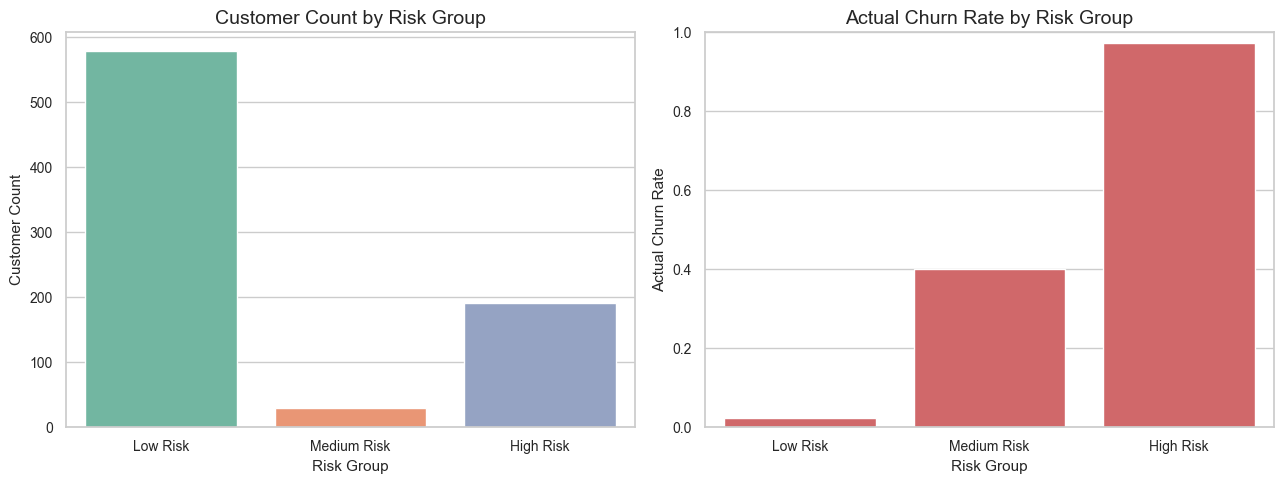

In [33]:
analysis_df["risk_group"] = pd.cut(
    analysis_df["churn_probability"],
    bins=[-np.inf, 0.3, 0.7, np.inf],
    labels=["Low Risk", "Medium Risk", "High Risk"],
)

risk_summary = analysis_df.groupby("risk_group", observed=False).agg(
    customer_count=("y_true", "count"),
    churn_rate_actual=("y_true", "mean"),
    avg_churn_probability=("churn_probability", "mean"),
).reset_index()
display(risk_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.countplot(data=analysis_df, x="risk_group", order=["Low Risk", "Medium Risk", "High Risk"], ax=axes[0], palette="Set2")
axes[0].set_title("Customer Count by Risk Group")
axes[0].set_xlabel("Risk Group")
axes[0].set_ylabel("Customer Count")

sns.barplot(data=risk_summary, x="risk_group", y="churn_rate_actual", order=["Low Risk", "Medium Risk", "High Risk"], ax=axes[1], color="#E15759")
axes[1].set_title("Actual Churn Rate by Risk Group")
axes[1].set_xlabel("Risk Group")
axes[1].set_ylabel("Actual Churn Rate")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "shap_risk_segmentation.png", dpi=150, bbox_inches="tight")
plt.show()


# 18. Retention Recommendation Logic

Tạo rule-based recommendation dựa trên top SHAP drivers. Đây là bước chuyển explainability thành hành động business cụ thể.


In [34]:
def generate_retention_recommendation(customer_explanation: pd.DataFrame) -> str:
    top_positive_features = customer_explanation[customer_explanation["shap_value"] > 0].head(8)["feature"].tolist()
    feature_set = set(top_positive_features)
    recommendations = []

    if {"frequency_drop", "low_current_activity", "ending_low_activity", "new_low_activity"} & feature_set:
        recommendations.append("Send re-engagement campaign or free personal training session")
    if {"is_contract_ending", "contract_remaining_ratio", "Month_to_end_contract", "renewal_pressure_score"} & feature_set:
        recommendations.append("Offer renewal discount before contract expires")
    if {"is_new_customer", "loyalty_score", "lifetime_per_contract", "log_lifetime"} & feature_set:
        recommendations.append("Onboarding follow-up and habit-building support")
    if {"far_no_group", "Group_visits", "no_group_low_activity", "social_commitment_score"} & feature_set:
        recommendations.append("Invite to group classes or community events")
    if {"spending_per_month", "low_spending"} & feature_set:
        recommendations.append("Offer bundled services or introductory add-ons")

    if not recommendations:
        recommendations.append("General retention call and personalized check-in")
    return " | ".join(dict.fromkeys(recommendations))

recommendation_rows = []
for customer_index in test_predictions.head(10).index:
    explanation = customer_shap_table(customer_index, top_n=10)
    top_positive = explanation[explanation["shap_value"] > 0].head(5)
    recommendation_rows.append({
        "customer_id": customer_index,
        "churn_probability": test_predictions.loc[customer_index, "churn_probability"],
        "actual_churn": test_predictions.loc[customer_index, "y_true"],
        "predicted_churn": test_predictions.loc[customer_index, "y_pred"],
        "top_risk_drivers": ", ".join(top_positive["feature"].tolist()),
        "recommendation": generate_retention_recommendation(explanation),
    })

customer_shap_explanations = pd.DataFrame(recommendation_rows)
customer_explanations_path = REPORTS_DIR / "customer_shap_explanations.csv"
customer_shap_explanations.to_csv(customer_explanations_path, index=False)
print(f"Saved customer SHAP explanations to: {customer_explanations_path}")
display(customer_shap_explanations)


Saved customer SHAP explanations to: D:\UIT SUBJECTS\Nam 2 - hoc ki 2 - Machine Learning\DoAn - GymCustomers and Churn\reports\customer_shap_explanations.csv


,customer_id,churn_probability,actual_churn,predicted_churn,top_risk_drivers,recommendation
0,3533,1.0000,1,1,"frequency_drop, Age, frequency_ratio_current_t...",Send re-engagement campaign or free personal t...
1,221,1.0000,1,1,"frequency_drop, frequency_ratio_current_total,...",Send re-engagement campaign or free personal t...
2,3205,1.0000,1,1,"frequency_drop, Age, frequency_ratio_current_t...",Send re-engagement campaign or free personal t...
3,1821,1.0000,1,1,"frequency_drop, frequency_ratio_current_total,...",Send re-engagement campaign or free personal t...
4,3870,1.0000,1,1,"frequency_drop, frequency_ratio_current_total,...",Send re-engagement campaign or free personal t...
5,3247,1.0000,1,1,"frequency_drop, frequency_ratio_current_total,...",Send re-engagement campaign or free personal t...
6,3876,1.0000,1,1,"frequency_drop, frequency_ratio_current_total,...",Send re-engagement campaign or free personal t...
7,46,1.0000,1,1,"frequency_drop, frequency_ratio_current_total,...",Send re-engagement campaign or free personal t...
8,2907,1.0000,1,1,"frequency_drop, frequency_ratio_current_total,...",Send re-engagement campaign or free personal t...
9,1204,0.9999,1,1,"frequency_drop, Age, loyalty_score, frequency_...",Send re-engagement campaign or free personal t...


# 19. Executive Summary

## 1. Model Performance

CatBoost + Feature Engineering là best model hiện tại, với performance tham chiếu khoảng ROC-AUC 0.9897, F1 0.9294, Recall 0.9009 và Accuracy 0.9637. Notebook này train lại model để phục vụ explainability.

## 2. Main Churn Drivers

Các churn drivers cần kiểm tra qua SHAP thường gồm:

- Attendance drop / frequency_drop.
- Low engagement.
- Contract ending soon.
- Low loyalty.
- Low current activity.

## 3. Business Meaning

Churn chủ yếu được thúc đẩy bởi hành vi giảm tương tác và rủi ro gia hạn hợp đồng. Khi khách ít đi tập hơn, gần hết hợp đồng hoặc chưa hình thành thói quen, nguy cơ churn thường tăng.

## 4. Recommended Actions

- Trigger re-engagement campaign khi attendance giảm.
- Tập trung chăm sóc khách hàng mới.
- Chạy renewal campaign trước khi hợp đồng hết hạn.
- Khuyến khích group visits và hoạt động cộng đồng.
- Cá nhân hóa retention offer theo SHAP explanation.

## 5. Deployment Implication

Model có thể dùng để tạo churn risk score. SHAP giúp giải thích lý do churn để retention team ưu tiên khách High Risk và chọn hành động phù hợp.


# 20. Final Conclusions

SHAP giúp xác nhận và làm rõ các insight từ EDA, feature engineering và modeling:

- Engineered features như frequency_drop, engagement_score và loyalty_score có ý nghĩa business rõ ràng.
- Model không chỉ dự đoán churn tốt mà còn có thể giải thích được ở cấp global và local.
- Local explanations giúp chuyển prediction thành action: chăm sóc khách mới, tái kích hoạt khách giảm attendance, hoặc chạy renewal campaign trước khi hợp đồng hết hạn.

Notebook tiếp theo nên tập trung vào:

- Threshold optimization theo chi phí business.
- Probability calibration.
- Final pipeline export.
- Streamlit deployment hoặc dashboard cho retention team.
